In [67]:
import pandas as pd
import numpy as np
from collections import Counter
import re
from tqdm import tqdm
import random

In [68]:
!pwd
!mkdir -p /content/data

/content


In [69]:
from google.colab import drive
drive.mount('/content/data')

Drive already mounted at /content/data; to attempt to forcibly remount, call drive.mount("/content/data", force_remount=True).


In [70]:
train_path = "./data/MyDrive/train.csv"
test_path = "./data/MyDrive/test.csv"
sample_sub_path = "./data/MyDrive/sample_submission.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_sub = pd.read_csv(sample_sub_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head(10)


Train shape: (11263, 3)
Test shape: (1689, 2)


,ID,input,output
0,TRAIN_00000,별 한 게토 았깝땀. 왜 싸람듯릭 펼 1캐를 쥰눈징 컥꺾폰 싸람믐롯섞 맒록 섧멍핥쟈...,별 한 개도 아깝다. 왜 사람들이 별 1개를 주는지 겪어본 사람으로서 말로 설명하자...
1,TRAIN_00001,잚많 쟉꼬 갉 태 좋눼욥. 차못동 줆 ㅋ,잠만 자고 갈 때 좋네요. 잠옷도 줌 ㅋ
2,TRAIN_00002,절테 간면 않 된는 굣 멥몫,절대 가면 안 되는 곳 메모
3,TRAIN_00003,야... 칵컥 좋꾜 부됴 뼝 뚫렷썹 신원햐쥠만 닮패 넴센 밌쪄벅림. 샥퀘 핥류만 묵...,아... 가격 좋고 뷰도 뻥 뚫려서 시원하지만 담배 냄새 미쳐버림. 싸게 하루만 묵...
4,TRAIN_00004,집윈 축쳐눌료 딴너왓눈뎁 카셩뷔 좋곱 칼쿰한네올. 쩌럼한뒈 뮬콰 욺료토 잊쿄 빻토 ...,지인 추천으로 다녀왔는데 가성비 좋고 깔끔하네요. 저렴한데 물과 음료도 있고 방도 ...
5,TRAIN_00005,펀냔휜 잘 쉭곶 왔쑵닝따. 준윙에 맏쥡됴 만학썩 좋흖 겼 갇따용.,편안히 잘 쉬고 왔습니다. 주위에 맛집도 많아서 좋은 것 같아요.
6,TRAIN_00006,"쓰윔튿룸위 깝써칙갖 있네 ㅋ 꼭굽 췸규웨 낑펙투, 합뻔퓨 옥쪽, 캬뻬 깥은 띰 떼잎...","스위트룸의 값어치가 있네 ㅋ 고급 침구에 킹베드, 하버뷰 욕조, 카페 같은 티 테이..."
7,TRAIN_00007,쨉빵뮨 의싸 쩐허 없쓺. 씬랏슬톄잎뾰댜 떠 짝음. 홈뗄 줄찾짱 15땜만 캉눙. 혹텔...,재방문 의사 전혀 없음. 신라스테이보다 더 작음. 호텔 주차장 15대만 가능. 호텔...
8,TRAIN_00008,념묵 멎쥑교 꽁귀 좋습니닸. 췐곡윕뉘댜!,너무 멋지고 공기 좋습니다. 최고입니다!
9,TRAIN_00009,"짱졈: 쩡켤함, 츄챠 씨셜 죠흠, 쉼섦 좋음. 단젊: 줏짢 츌짜할 떼 뷸뻔함, ...","장점: 청결함, 주차 시설 좋음, 시설 좋음. 단점: 주차 출차할 때 불편함, ..."


In [71]:
print("=== train.info ===")
print(train.info())

print("\n=== Null counts (train) ===")
print(train.isnull().sum())

print("\n=== Null counts (test) ===")
print(test.isnull().sum())


=== train.info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11263 entries, 0 to 11262
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      11263 non-null  object
 1   input   11263 non-null  object
 2   output  11263 non-null  object
dtypes: object(3)
memory usage: 264.1+ KB
None

=== Null counts (train) ===
ID        0
input     0
output    0
dtype: int64

=== Null counts (test) ===
ID       0
input    0
dtype: int64


In [72]:
def normalize_text(s: str) -> str:
    if not isinstance(s, str):
        s = str(s)
    s = s.replace("\u200b", "") # zero-width space 제거
    s = re.sub(r"\s+", " ", s) # 여러 공백 -> 하나
    return s.strip()

def remove_spaces(s: str) -> str:
    if not isinstance(s, str):
        s = str(s)
    return re.sub(r"\s+", "", s)

print(normalize_text("   안 녕   하   세  요  "))

안 녕 하 세 요


In [73]:
# 한글 음절 구성 상수 (Unicode Hangul Syllables)
S_BASE = 0xAC00
L_BASE = 0x1100
V_BASE = 0x1161
T_BASE = 0x11A7
L_COUNT = 19
V_COUNT = 21
T_COUNT = 28
N_COUNT = V_COUNT * T_COUNT
S_COUNT = L_COUNT * N_COUNT

# 사람 눈에 익숙한 'ㄱ,ㄴ,ㅏ,ㅏ...' 형태의 자모 리스트 (호환 자모)
CHOSUNG_LIST = list("ㄱㄲㄴㄷㄸㄹㅁㅂㅃㅅㅆㅇㅈㅉㅊㅋㅌㅍㅎ")
JUNGSUNG_LIST = list("ㅏㅐㅑㅒㅓㅔㅕㅖㅗㅘㅙㅚㅛㅜㅝㅞㅟㅠㅡㅢㅣ")
JONGSUNG_LIST = ["", "ㄱ", "ㄲ", "ㄳ", "ㄴ", "ㄵ", "ㄶ", "ㄷ", "ㄹ",
                 "ㄺ", "ㄻ", "ㄼ", "ㄽ", "ㄾ", "ㄿ", "ㅀ",
                 "ㅁ", "ㅂ", "ㅄ", "ㅅ", "ㅆ", "ㅇ", "ㅈ",
                 "ㅊ", "ㅋ", "ㅌ", "ㅍ", "ㅎ"]

def is_hangul_syllable(ch: str) -> bool:
    """가-힣 범위의 한글 음절인지 체크."""
    if not ch or len(ch) != 1:
        return False
    code = ord(ch)
    return S_BASE <= code <= (S_BASE + S_COUNT - 1)

def decompose_char(ch: str):
    """
    한글 음절 1글자를 (초성, 중성, 종성)으로 분리.
    - 한글이 아니면 None 반환.
    - 종성이 없으면 T는 ''(빈 문자열).
    """
    if not is_hangul_syllable(ch):
        return None

    code = ord(ch) - S_BASE
    l_index = code // N_COUNT
    v_index = (code % N_COUNT) // T_COUNT
    t_index = code % T_COUNT

    L = CHOSUNG_LIST[l_index]
    V = JUNGSUNG_LIST[v_index]
    T = JONGSUNG_LIST[t_index]
    return L, V, T

def compose_char(L: str, V: str, T: str = "") -> str:
    """
    (초성, 중성, 종성) 자모를 한글 음절로 조합.
    L,V,T는 위에 정의한 리스트의 원소여야 한다.
    """
    try:
        l_index = CHOSUNG_LIST.index(L)
        v_index = JUNGSUNG_LIST.index(V)
        t_index = JONGSUNG_LIST.index(T)
    except ValueError:
        # 리스트에 없는 자모면 조합 불가
        return ""

    code = S_BASE + (l_index * N_COUNT) + (v_index * T_COUNT) + t_index
    return chr(code)

# 간단 테스트
ch = "캠"
dec = decompose_char(ch)
print("원글자:", ch, "->", dec)
print("재조합:", compose_char(*dec))


원글자: 캠 -> ('ㅋ', 'ㅐ', 'ㅁ')
재조합: 캠


In [74]:
def decompose_string_to_jamo_triplets(s: str):
    """
    문자열 s를 순회하면서
    - 한글 음절이면 (L, V, T)
    - 아니면 (None, None, None)
    형태를 리스트로 반환.
    """
    result = []
    for ch in s:
        d = decompose_char(ch)
        if d is None:
            result.append((None, None, None, ch))  # 원문자도 같이 보관
        else:
            L, V, T = d
            result.append((L, V, T, ch))
    return result

sample_row = train.iloc[0]
print("ID:", sample_row["ID"])
print("[INPUT ]", sample_row["input"])
print("[OUTPUT]", sample_row["output"])

print("\n[INPUT 자모 분해 예시]")
for L, V, T, ch in decompose_string_to_jamo_triplets(remove_spaces(normalize_text(sample_row["input"]))[:20]):
    print(f"{ch}: ({L}, {V}, {T})")


ID: TRAIN_00000
[INPUT ] 별 한 게토 았깝땀. 왜 싸람듯릭 펼 1캐를 쥰눈징 컥꺾폰 싸람믐롯섞 맒록 섧멍핥쟈닐 탯끎룐눈 녀뮤 퀼교... 야뭍툰 둠 변 닺씨 깍낄 싫훈 굣. 깸삥읊 20여 년 댜녁뵨 곧 중 쩨윌 귑푼 낙팠떤 곶.
[OUTPUT] 별 한 개도 아깝다. 왜 사람들이 별 1개를 주는지 겪어본 사람으로서 말로 설명하자니 댓글로는 너무 길고... 아무튼 두 번 다시 가길 싫은 곳. 캠핑을 20여 년 다녀본 곳 중 제일 기분 나빴던 곳.

[INPUT 자모 분해 예시]
별: (ㅂ, ㅕ, ㄹ)
한: (ㅎ, ㅏ, ㄴ)
게: (ㄱ, ㅔ, )
토: (ㅌ, ㅗ, )
았: (ㅇ, ㅏ, ㅆ)
깝: (ㄲ, ㅏ, ㅂ)
땀: (ㄸ, ㅏ, ㅁ)
.: (None, None, None)
왜: (ㅇ, ㅙ, )
싸: (ㅆ, ㅏ, )
람: (ㄹ, ㅏ, ㅁ)
듯: (ㄷ, ㅡ, ㅅ)
릭: (ㄹ, ㅣ, ㄱ)
펼: (ㅍ, ㅕ, ㄹ)
1: (None, None, None)
캐: (ㅋ, ㅐ, )
를: (ㄹ, ㅡ, ㄹ)
쥰: (ㅈ, ㅠ, ㄴ)
눈: (ㄴ, ㅜ, ㄴ)
징: (ㅈ, ㅣ, ㅇ)


In [75]:
def align_text_pair_for_jamo(inp: str, out: str):
    """
    - 공백 제거 후, 같은 인덱스의 문자 쌍 리스트를 반환.
    - 길이가 다르면 더 짧은 길이까지만 사용.
    """
    inp_c = remove_spaces(normalize_text(inp))
    out_c = remove_spaces(normalize_text(out))
    L = min(len(inp_c), len(out_c))
    return inp_c[:L], out_c[:L]

# 예시 확인
inp_aligned, out_aligned = align_text_pair_for_jamo(sample_row["input"], sample_row["output"])
print("aligned input :", inp_aligned[:50])
print("aligned output:", out_aligned[:50])
print("len:", len(inp_aligned), len(out_aligned))


aligned input : 별한게토았깝땀.왜싸람듯릭펼1캐를쥰눈징컥꺾폰싸람믐롯섞맒록섧멍핥쟈닐탯끎룐눈녀뮤퀼교...야뭍툰둠
aligned output: 별한개도아깝다.왜사람들이별1개를주는지겪어본사람으로서말로설명하자니댓글로는너무길고...아무튼두
len: 80 80


In [76]:
from collections import Counter
from tqdm import tqdm

def collect_jamo_change_stats(df, sample_n=None, random_state=42):
    """
    df: train DataFrame
    sample_n: 일부만 샘플링해서 볼 경우 정수. None이면 전체 사용.

    반환:
      - L_changes: Counter((L_in, L_out) -> count), 단 L_in != L_out 인 경우만
      - V_changes: Counter((V_in, V_out) -> count), 단 V_in != V_out 인 경우만
      - T_changes: Counter((T_in, T_out) -> count), 단 T_in != T_out 인 경우만
      - L_totals: Counter(L_in -> count)  # input에서 각 초성이 등장한 총 횟수
      - V_totals: Counter(V_in -> count)
      - T_totals: Counter(T_in -> count)
      - total_pairs, hangul_pairs
    """
    if sample_n is not None:
        df_iter = df.sample(sample_n, random_state=random_state)
    else:
        df_iter = df

    L_changes = Counter()
    V_changes = Counter()
    T_changes = Counter()

    L_totals = Counter()
    V_totals = Counter()
    T_totals = Counter()

    total_pairs = 0
    hangul_pairs = 0

    for inp, out in tqdm(zip(df_iter["input"], df_iter["output"]), total=len(df_iter)):
        inp_aligned, out_aligned = align_text_pair_for_jamo(inp, out)
        L = len(inp_aligned)
        total_pairs += L

        for i in range(L):
            ch_in = inp_aligned[i]
            ch_out = out_aligned[i]

            d_in = decompose_char(ch_in)
            d_out = decompose_char(ch_out)

            if d_in is None or d_out is None:
                continue  # 둘 중 하나라도 한글 음절이 아니면 스킵

            hangul_pairs += 1

            L_in, V_in, T_in = d_in
            L_out, V_out, T_out = d_out

            # input 기준 "얼마나 등장했는지"는 따로 전부 기록
            L_totals[L_in] += 1
            V_totals[V_in] += 1
            T_totals[T_in] += 1

            # 실제로 "변화한 경우"만 변화 카운터에 기록
            if L_in != L_out:
                L_changes[(L_in, L_out)] += 1
            if V_in != V_out:
                V_changes[(V_in, V_out)] += 1
            if T_in != T_out:
                T_changes[(T_in, T_out)] += 1

    stats = {
        "L_changes": L_changes,
        "V_changes": V_changes,
        "T_changes": T_changes,
        "L_totals": L_totals,
        "V_totals": V_totals,
        "T_totals": T_totals,
        "total_pairs": total_pairs,
        "hangul_pairs": hangul_pairs,
    }
    return stats

# 실행 (처음엔 sample_n으로 가볍게 돌려봐도 좋고, 전부 돌려도 됨)
jamo_stats = collect_jamo_change_stats(train, sample_n=None)
jamo_stats["total_pairs"], jamo_stats["hangul_pairs"]

100%|██████████| 11263/11263 [00:01<00:00, 5893.39it/s]


(795735, 724455)

In [77]:
jamo_stats["L_totals"]
jamo_stats["L_changes"]

Counter({('ㅌ', 'ㄷ'): 18792,
         ('ㄸ', 'ㄷ'): 15435,
         ('ㅆ', 'ㅅ'): 26688,
         ('ㄹ', 'ㅇ'): 5008,
         ('ㅍ', 'ㅂ'): 10603,
         ('ㅋ', 'ㄱ'): 21142,
         ('ㄲ', 'ㅇ'): 1142,
         ('ㅁ', 'ㅇ'): 2963,
         ('ㄲ', 'ㄱ'): 22606,
         ('ㅎ', 'ㅇ'): 2784,
         ('ㄲ', 'ㅋ'): 3299,
         ('ㅃ', 'ㅍ'): 3284,
         ('ㅉ', 'ㅈ'): 13288,
         ('ㅍ', 'ㅃ'): 1040,
         ('ㅌ', 'ㄸ'): 2388,
         ('ㅊ', 'ㅈ'): 15481,
         ('ㅉ', 'ㅊ'): 10363,
         ('ㅅ', 'ㅆ'): 1025,
         ('ㄸ', 'ㅌ'): 5724,
         ('ㅊ', 'ㅉ'): 1347,
         ('ㅅ', 'ㅇ'): 3202,
         ('ㄴ', 'ㅇ'): 4316,
         ('ㅋ', 'ㄲ'): 4498,
         ('ㅃ', 'ㅂ'): 8868,
         ('ㅃ', 'ㅇ'): 513,
         ('ㅆ', 'ㅇ'): 2653,
         ('ㄸ', 'ㅇ'): 430,
         ('ㅂ', 'ㅇ'): 338,
         ('ㅋ', 'ㅎ'): 896,
         ('ㅌ', 'ㅇ'): 512,
         ('ㄲ', 'ㅎ'): 983,
         ('ㅊ', 'ㅇ'): 88,
         ('ㄱ', 'ㅇ'): 2138,
         ('ㅍ', 'ㅇ'): 695,
         ('ㄷ', 'ㅇ'): 118,
         ('ㅋ', 'ㅇ'): 1228,
         ('ㅃ', 'ㅎ'): 135,
   

In [78]:
# 초/중/종성별 변화 패턴 요약 함수
def summarize_axis_changes(changes: Counter, totals: Counter, axis_name="초성(L)", top_k_dst=5):
    """
    changes: Counter((src, dst) -> count), src != dst
    totals: Counter(src -> total_count)
    """
    print(f"=== {axis_name}별 변화 패턴 ===")
    for src, total in totals.most_common():  # 자주 쓰이는 순
        # src에서 dst로 "변화한" 것들만 모음
        rows = []
        changed_sum = 0
        for (s, dst), cnt in changes.items():
            if s != src:
                continue
            rows.append((dst, cnt, cnt / total))
            changed_sum += cnt
        rows.sort(key=lambda x: x[1], reverse=True)

        unchanged = total - changed_sum

        print(f"\n[{axis_name} = '{src if src != '' else '(없음)'}']  총 {total}회")
        print(f"  - 그대로 유지: {unchanged}회 ({unchanged/total:.3f})")
        if rows:
            print(f"  - 변화 패턴 상위 {min(top_k_dst, len(rows))}개:")
            for dst, cnt, ratio in rows[:top_k_dst]:
                dst_disp = dst if dst != "" else "(없음)"
                print(f"      -> '{dst_disp}': {cnt}회 ({ratio:.3f})")
        else:
            print("  - 변화한 적 없음")

# 초성 요약 예시
summarize_axis_changes(jamo_stats["L_changes"], jamo_stats["L_totals"], axis_name="초성(L)", top_k_dst=5)


=== 초성(L)별 변화 패턴 ===

[초성(L) = 'ㅇ']  총 134565회
  - 그대로 유지: 134565회 (1.000)
  - 변화한 적 없음

[초성(L) = 'ㄴ']  총 55930회
  - 그대로 유지: 51614회 (0.923)
  - 변화 패턴 상위 1개:
      -> 'ㅇ': 4316회 (0.077)

[초성(L) = 'ㅎ']  총 45207회
  - 그대로 유지: 42423회 (0.938)
  - 변화 패턴 상위 1개:
      -> 'ㅇ': 2784회 (0.062)

[초성(L) = 'ㄱ']  총 45158회
  - 그대로 유지: 43020회 (0.953)
  - 변화 패턴 상위 1개:
      -> 'ㅇ': 2138회 (0.047)

[초성(L) = 'ㅅ']  총 44775회
  - 그대로 유지: 40548회 (0.906)
  - 변화 패턴 상위 2개:
      -> 'ㅇ': 3202회 (0.072)
      -> 'ㅆ': 1025회 (0.023)

[초성(L) = 'ㄹ']  총 40738회
  - 그대로 유지: 35730회 (0.877)
  - 변화 패턴 상위 1개:
      -> 'ㅇ': 5008회 (0.123)

[초성(L) = 'ㅁ']  총 39694회
  - 그대로 유지: 36731회 (0.925)
  - 변화 패턴 상위 1개:
      -> 'ㅇ': 2963회 (0.075)

[초성(L) = 'ㄲ']  총 34818회
  - 그대로 유지: 6788회 (0.195)
  - 변화 패턴 상위 4개:
      -> 'ㄱ': 22606회 (0.649)
      -> 'ㅋ': 3299회 (0.095)
      -> 'ㅇ': 1142회 (0.033)
      -> 'ㅎ': 983회 (0.028)

[초성(L) = 'ㅈ']  총 33684회
  - 그대로 유지: 33574회 (0.997)
  - 변화 패턴 상위 1개:
      -> 'ㅇ': 110회 (0.003)

[초성(L) = 'ㄷ']  총 32698회
 

In [79]:
def change_ratio_summary(changes: Counter, totals: Counter, axis_label="초성(L)"):
    total = sum(totals.values())
    changed = sum(changes.values())
    unchanged = total - changed

    print(f"[{axis_label}] 전체 쌍 기준:")
    print(f"  - 등장 총합: {total}")
    print(f"  - 그대로 유지: {unchanged} ({unchanged/total:.4f})")
    print(f"  - 변경됨      : {changed} ({changed/total:.4f})")

print("=== 초성(L) 변화 비율 ===")
change_ratio_summary(jamo_stats["L_changes"], jamo_stats["L_totals"], axis_label="초성(L)")

print("\n=== 중성(V) 변화 비율 ===")
change_ratio_summary(jamo_stats["V_changes"], jamo_stats["V_totals"], axis_label="중성(V)")

print("\n=== 종성(T) 변화 비율 ===")
change_ratio_summary(jamo_stats["T_changes"], jamo_stats["T_totals"], axis_label="종성(T)")


=== 초성(L) 변화 비율 ===
[초성(L)] 전체 쌍 기준:
  - 등장 총합: 724455
  - 그대로 유지: 508136 (0.7014)
  - 변경됨      : 216319 (0.2986)

=== 중성(V) 변화 비율 ===
[중성(V)] 전체 쌍 기준:
  - 등장 총합: 724455
  - 그대로 유지: 436243 (0.6022)
  - 변경됨      : 288212 (0.3978)

=== 종성(T) 변화 비율 ===
[종성(T)] 전체 쌍 기준:
  - 등장 총합: 724455
  - 그대로 유지: 444544 (0.6136)
  - 변경됨      : 279911 (0.3864)


In [80]:
!apt-get -qq -y install fonts-nanum

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import glob

# 2) 시스템에 설치된 Nanum 폰트 파일 경로 확인
font_paths = glob.glob("/usr/share/fonts/truetype/nanum/*.ttf")
print("Found Nanum font files:")
for p in font_paths:
    print("  ", p)

# 3) Matplotlib에 폰트 등록
for path in font_paths:
    fm.fontManager.addfont(path)

# 4) Matplotlib이 인식한 'Nanum' 계열 폰트 이름 확인
nanum_fonts = sorted({f.name for f in fm.fontManager.ttflist if "Nanum" in f.name})
print("\nMatplotlib recognizes these Nanum font names:")
for name in nanum_fonts:
    print("  ", name)

# 5) 그 중 하나를 기본 폰트로 설정 (보통 'NanumGothic' 또는 비슷한 이름이 있을 것)
#    없으면 그냥 첫 번째 Nanum 계열 이름을 사용
if nanum_fonts:
    default_nanum = nanum_fonts[0]
    print(f"\nUsing '{default_nanum}' as default font.")
    mpl.rcParams["font.family"] = default_nanum
else:
    print("\nNo Nanum fonts found in Matplotlib. Falling back to default font.")

# 6) 마이너스 깨짐 방지
mpl.rcParams["axes.unicode_minus"] = False


Found Nanum font files:
   /usr/share/fonts/truetype/nanum/NanumGothicBold.ttf
   /usr/share/fonts/truetype/nanum/NanumSquareR.ttf
   /usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf
   /usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf
   /usr/share/fonts/truetype/nanum/NanumMyeongjoBold.ttf
   /usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf
   /usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf
   /usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf
   /usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf
   /usr/share/fonts/truetype/nanum/NanumSquareB.ttf
   /usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf
   /usr/share/fonts/truetype/nanum/NanumGothic.ttf

Matplotlib recognizes these Nanum font names:
   NanumBarunGothic
   NanumGothic
   NanumGothicCoding
   NanumMyeongjo
   NanumSquare
   NanumSquareRound

Using 'NanumBarunGothic' as default font.


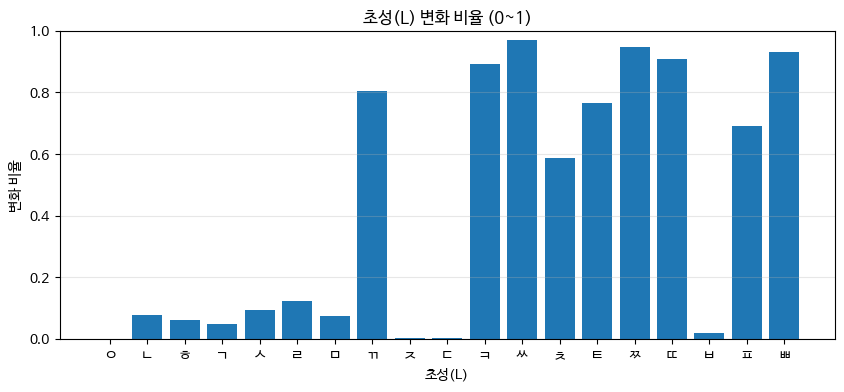

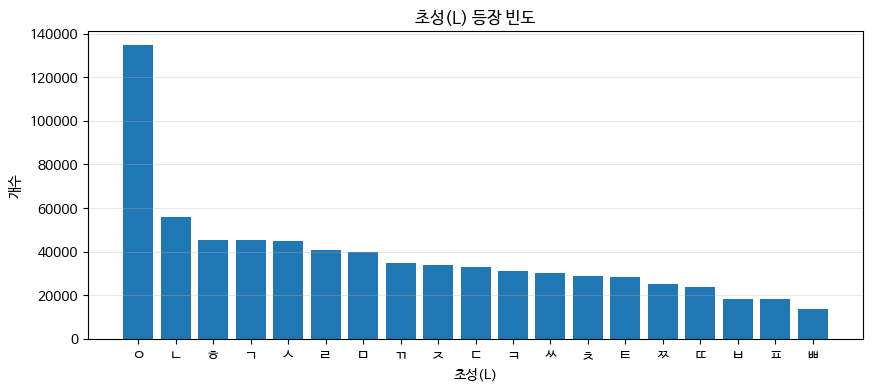

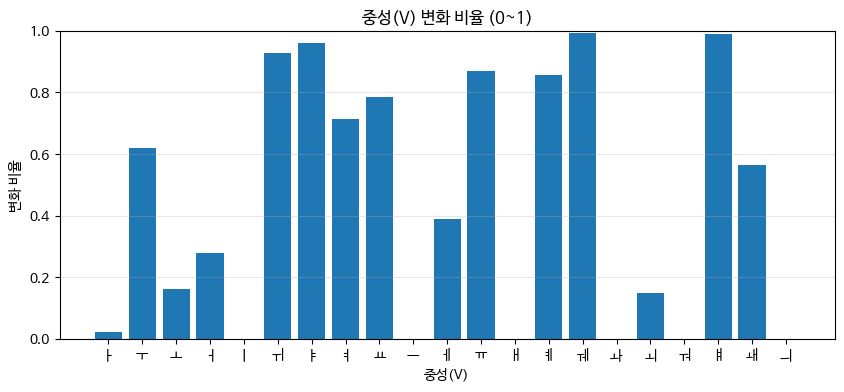

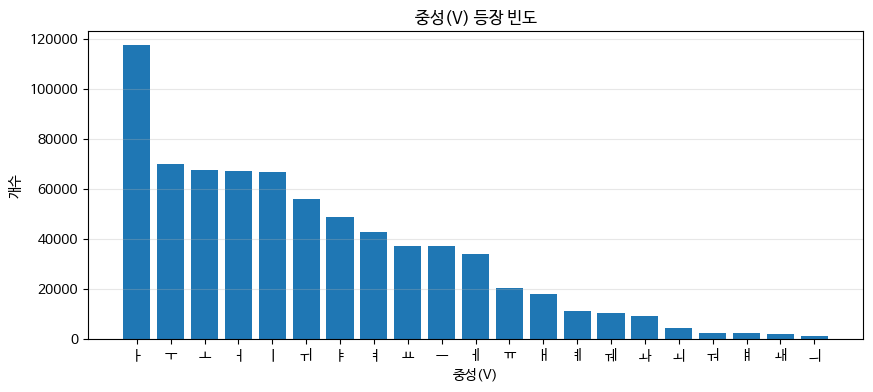

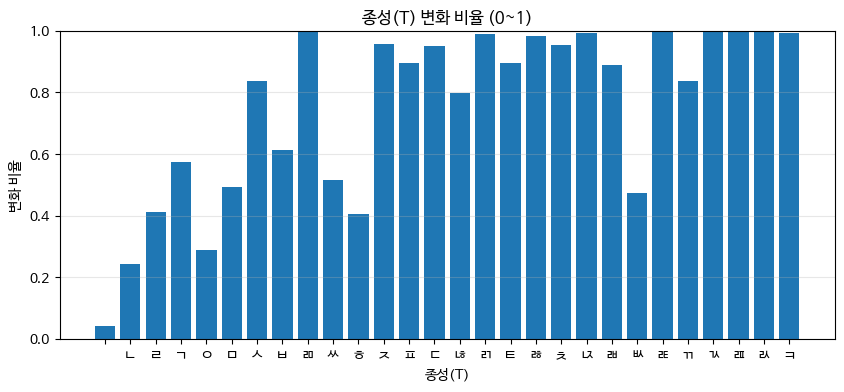

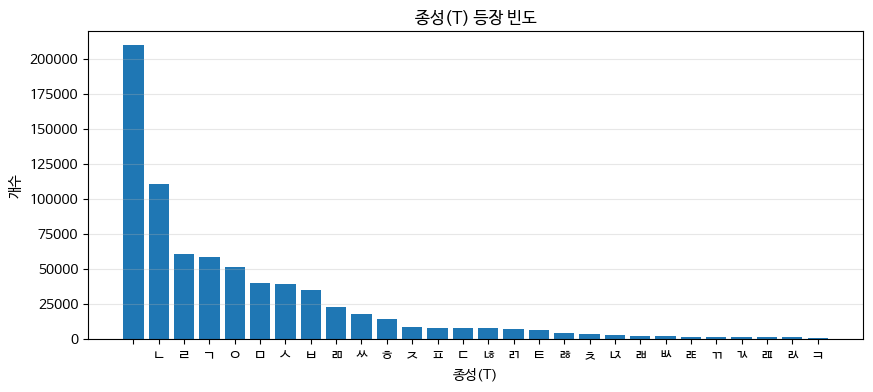

In [81]:
import numpy as np
import matplotlib.pyplot as plt

def plot_change_ratio_per_src(changes: Counter, totals: Counter, axis_label="초성(L)"):
    """
    changes: Counter((src, dst) -> count)
    totals: Counter(src -> total_count)
    axis_label: "초성(L)", "중성(V)", "종성(T)" 등 한글로 써도 됨
    """
    srcs = [s for s, _ in totals.most_common()]  # 많이 등장한 순
    ratios = []
    counts = []

    for src in srcs:
        total = totals[src]
        changed = sum(cnt for (s, dst), cnt in changes.items() if s == src)
        ratio = changed / total if total > 0 else 0.0
        ratios.append(ratio)
        counts.append(total)

    x = np.arange(len(srcs))

    # 변화 비율 그래프
    plt.figure(figsize=(10, 4))
    plt.bar(x, ratios)
    plt.xticks(x, srcs)
    plt.ylim(0, 1)
    plt.title(f"{axis_label} 변화 비율 (0~1)")
    plt.xlabel(axis_label)
    plt.ylabel("변화 비율")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    # 등장 빈도 그래프
    plt.figure(figsize=(10, 4))
    plt.bar(x, counts)
    plt.xticks(x, srcs)
    plt.title(f"{axis_label} 등장 빈도")
    plt.xlabel(axis_label)
    plt.ylabel("개수")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

# 사용 예시
plot_change_ratio_per_src(jamo_stats["L_changes"], jamo_stats["L_totals"], axis_label="초성(L)")
plot_change_ratio_per_src(jamo_stats["V_changes"], jamo_stats["V_totals"], axis_label="중성(V)")
plot_change_ratio_per_src(jamo_stats["T_changes"], jamo_stats["T_totals"], axis_label="종성(T)")


In [82]:
def find_examples_for_L_change(df, L_in, L_out, max_examples=5):
    """
    초성이 L_in -> L_out 으로 바뀐 위치가 있는 샘플 몇 개 출력.
    (중성/종성은 동일할 필요 없음, 그냥 참고 정보로 출력)
    """
    count = 0
    for _, row in df.iterrows():
        inp_aligned, out_aligned = align_text_pair_for_jamo(row["input"], row["output"])
        L = len(inp_aligned)
        found = False
        pos = None
        d_in_hit = None
        d_out_hit = None
        ch_in_hit = None
        ch_out_hit = None

        for i in range(L):
            ch_in = inp_aligned[i]
            ch_out = out_aligned[i]
            d_in = decompose_char(ch_in)
            d_out = decompose_char(ch_out)
            if d_in is None or d_out is None:
                continue

            Li, Vi, Ti = d_in
            Lo, Vo, To = d_out

            # 초성 변화만 조건으로 사용
            if Li == L_in and Lo == L_out:
                found = True
                pos = i
                d_in_hit = d_in
                d_out_hit = d_out
                ch_in_hit = ch_in
                ch_out_hit = ch_out
                break

        if found:
            print("="*80)
            print("ID:", row["ID"])
            print("[INPUT ]", row["input"])
            print("[OUTPUT]", row["output"])
            print(
                f"  -> 위치 {pos}에서 '{ch_in_hit}'{d_in_hit} -> "
                f"'{ch_out_hit}'{d_out_hit}"
            )
            count += 1
            if count >= max_examples:
                break

    if count == 0:
        print(f"초성 {L_in!r} -> {L_out!r} 변화 패턴을 가진 예시를 찾지 못했습니다.")

# 예시: ㄱ -> ㄲ 패턴이 실제로 있으면 출력, 없으면 '못찾음' 메시지
find_examples_for_L_change(train, "ㄱ", "ㄲ", max_examples=3)


초성 'ㄱ' -> 'ㄲ' 변화 패턴을 가진 예시를 찾지 못했습니다.


       char_change_ratio  char_same_count  char_total_aligned
count       11263.000000     11263.000000        11263.000000
mean            0.788190        14.467105           70.650360
std             0.077295        16.000121           73.516704
min             0.000000         0.000000            1.000000
25%             0.750000         5.000000           26.000000
50%             0.800000        10.000000           48.000000
75%             0.833333        18.000000           89.000000
max             1.000000       321.000000         1057.000000


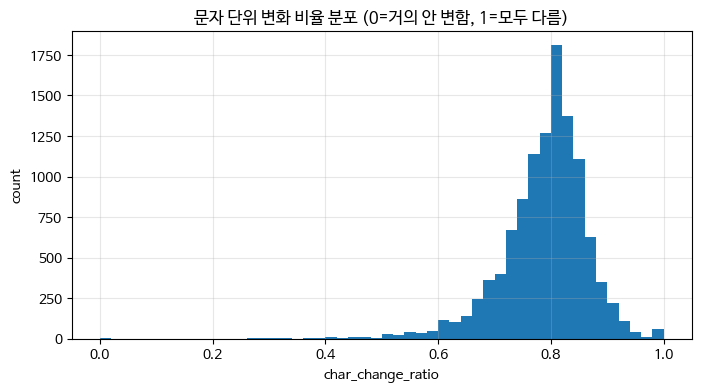

In [83]:
def char_change_ratio_row(inp: str, out: str):
    inp_c = remove_spaces(normalize_text(inp))
    out_c = remove_spaces(normalize_text(out))
    L = min(len(inp_c), len(out_c))
    if L == 0:
        return 0.0, 0, 0  # ratio, same, total

    same = sum(1 for i in range(L) if inp_c[i] == out_c[i])
    total = L
    ratio_same = same / total
    return 1.0 - ratio_same, same, total  # change_ratio, same, total

# train에 적용
change_ratios = []
same_counts = []
total_counts = []

for inp, out in zip(train["input"], train["output"]):
    r, same, tot = char_change_ratio_row(inp, out)
    change_ratios.append(r)
    same_counts.append(same)
    total_counts.append(tot)

train["char_change_ratio"] = change_ratios
train["char_same_count"] = same_counts
train["char_total_aligned"] = total_counts

print(train[["char_change_ratio", "char_same_count", "char_total_aligned"]].describe())

# 히스토그램 시각화
plt.figure(figsize=(8,4))
plt.hist(train["char_change_ratio"], bins=50)
plt.title("문자 단위 변화 비율 분포 (0=거의 안 변함, 1=모두 다름)")
plt.xlabel("char_change_ratio")
plt.ylabel("count")
plt.grid(alpha=0.3)
plt.show()

In [84]:
def show_extreme_samples(df, col="char_change_ratio", n=5):
    print("="*30, "변화 적은 리뷰", "="*30)
    low = df.sort_values(col, ascending=True).head(n)
    for _, row in low.iterrows():
        print("-"*80)
        print(f"ID: {row['ID']}  change_ratio={row[col]:.3f}")
        print("[INPUT ]", row["input"])
        print("[OUTPUT]", row["output"])

    print("\n", "="*30, "변화 많은 리뷰", "="*30)
    high = df.sort_values(col, ascending=False).head(n)
    for _, row in high.iterrows():
        print("-"*80)
        print(f"ID: {row['ID']}  change_ratio={row[col]:.3f}")
        print("[INPUT ]", row["input"])
        print("[OUTPUT]", row["output"])

show_extreme_samples(train, col="char_change_ratio", n=10)

============================== 변화 적은 리뷰 ==============================
--------------------------------------------------------------------------------
ID: TRAIN_06765  change_ratio=0.000
[INPUT ] 010-7592-3341
[OUTPUT] 010-7592-3341
--------------------------------------------------------------------------------
ID: TRAIN_09531  change_ratio=0.000
[INPUT ] GGH....?
[OUTPUT] GGH....?
--------------------------------------------------------------------------------
ID: TRAIN_00303  change_ratio=0.160
[INPUT ] 꺅걱 데삐.....................
[OUTPUT] 가격 대비.....................
--------------------------------------------------------------------------------
ID: TRAIN_02422  change_ratio=0.231
[INPUT ] 좋숲뉘타!!!!!!!!!
[OUTPUT] 좋습니다!!!!!!!!!
--------------------------------------------------------------------------------
ID: TRAIN_00814  change_ratio=0.250
[INPUT ] 좋악요!
[OUTPUT] 좋아요!
--------------------------------------------------------------------------------
ID: TRAIN_02852  change_ratio=0.267

In [85]:
def jamo_change_ratio_row(inp: str, out: str):
    """
    한 리뷰에서 초성/중성/종성이 각각 얼마나 바뀌었는지 비율로 계산.
    반환: (L_changed/total_L, V_changed/total_V, T_changed/total_T)
    """
    inp_aligned, out_aligned = align_text_pair_for_jamo(inp, out)
    L = len(inp_aligned)

    total_L = total_V = total_T = 0
    changed_L = changed_V = changed_T = 0

    for i in range(L):
        ch_in = inp_aligned[i]
        ch_out = out_aligned[i]
        d_in = decompose_char(ch_in)
        d_out = decompose_char(ch_out)
        if d_in is None or d_out is None:
            continue

        Li, Vi, Ti = d_in
        Lo, Vo, To = d_out

        # 초성
        total_L += 1
        if Li != Lo:
            changed_L += 1

        # 중성
        total_V += 1
        if Vi != Vo:
            changed_V += 1

        # 종성
        total_T += 1
        if Ti != To:
            changed_T += 1

    def safe_ratio(changed, total):
        if total == 0:
            return 0.0
        return changed / total

    return (
        safe_ratio(changed_L, total_L),
        safe_ratio(changed_V, total_V),
        safe_ratio(changed_T, total_T),
        total_L,
    )

L_ratios = []
V_ratios = []
T_ratios = []
L_totals = []

for inp, out in zip(train["input"], train["output"]):
    rL, rV, rT, tL = jamo_change_ratio_row(inp, out)
    L_ratios.append(rL)
    V_ratios.append(rV)
    T_ratios.append(rT)
    L_totals.append(tL)

train["L_change_ratio"] = L_ratios
train["V_change_ratio"] = V_ratios
train["T_change_ratio"] = T_ratios
train["L_count"] = L_totals

train[["L_change_ratio", "V_change_ratio", "T_change_ratio"]].describe()

,L_change_ratio,V_change_ratio,T_change_ratio
count,11263.000000,11263.000000,11263.000000
mean,0.298773,0.394145,0.384389
std,0.082250,0.089214,0.089655
min,0.000000,0.000000,0.000000
25%,0.250483,0.346939,0.333333
50%,0.297297,0.395349,0.384615
75%,0.341463,0.442857,0.434783
max,1.000000,1.000000,1.000000


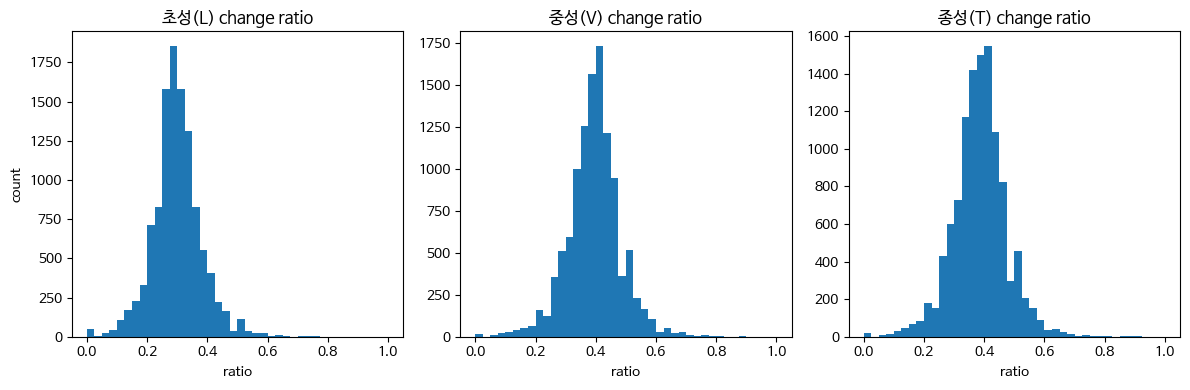

In [86]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(train["L_change_ratio"], bins=40)
plt.title("초성(L) change ratio")
plt.xlabel("ratio")
plt.ylabel("count")

plt.subplot(1,3,2)
plt.hist(train["V_change_ratio"], bins=40)
plt.title("중성(V) change ratio")
plt.xlabel("ratio")

plt.subplot(1,3,3)
plt.hist(train["T_change_ratio"], bins=40)
plt.title("종성(T) change ratio")
plt.xlabel("ratio")

plt.tight_layout()
plt.show()

In [87]:
import math


def compute_axis_entropy(changes: Counter, totals: Counter):
    """
    각 src 자모별로 P(dst | src)의 엔트로피를 계산.
    dst에는 '자기 자신'도 포함.
    반환: dict[src] = entropy (bits)
    """
    ent = {}

    # src별로 모음
    dst_by_src = {}
    for (src, dst), cnt in changes.items():
        dst_by_src.setdefault(src, {})
        dst_by_src[src][dst] = dst_by_src[src].get(dst, 0) + cnt

    for src, total in totals.items():
        if total == 0:
            ent[src] = 0.0
            continue

        # 자기 자신으로 유지된 횟수
        changed_sum = sum(dst_by_src.get(src, {}).values())
        same_count = total - changed_sum

        # 분포 구성
        probs = []
        if same_count > 0:
            probs.append(same_count / total)
        for dst, cnt in dst_by_src.get(src, {}).items():
            probs.append(cnt / total)

        # 엔트로피 계산
        H = 0.0
        for p in probs:
            if p > 0:
                H -= p * math.log2(p)
        ent[src] = H

    return ent

L_entropy = compute_axis_entropy(jamo_stats["L_changes"], jamo_stats["L_totals"])
V_entropy = compute_axis_entropy(jamo_stats["V_changes"], jamo_stats["V_totals"])
T_entropy = compute_axis_entropy(jamo_stats["T_changes"], jamo_stats["T_totals"])

print("초성(L) 엔트로피 상위/하위 몇 개")
print(sorted(L_entropy.items(), key=lambda x: x[1])[:10])   # entropy 낮은 (규칙적)
print(sorted(L_entropy.items(), key=lambda x: x[1], reverse=True)[:10])  # 높은 (복잡)

초성(L) 엔트로피 상위/하위 몇 개
[('ㅇ', 0.0), ('ㅈ', 0.03167268803354839), ('ㄷ', 0.034479617473000504), ('ㅂ', 0.13410071589938494), ('ㄱ', 0.2750092883967764), ('ㅎ', 0.3336985536078871), ('ㅁ', 0.383027322809401), ('ㄴ', 0.39212059544480726), ('ㅅ', 0.5264503302564325), ('ㄹ', 0.5377302281218981)]
[('ㄲ', 1.4935607700814948), ('ㅋ', 1.461067589546598), ('ㅍ', 1.4463469160282973), ('ㅃ', 1.4078685478678925), ('ㄸ', 1.3209352828075185), ('ㅌ', 1.2878812749927169), ('ㅉ', 1.2538756512994333), ('ㅊ', 1.2406275188239297), ('ㅆ', 0.6172918412530646), ('ㄹ', 0.5377302281218981)]


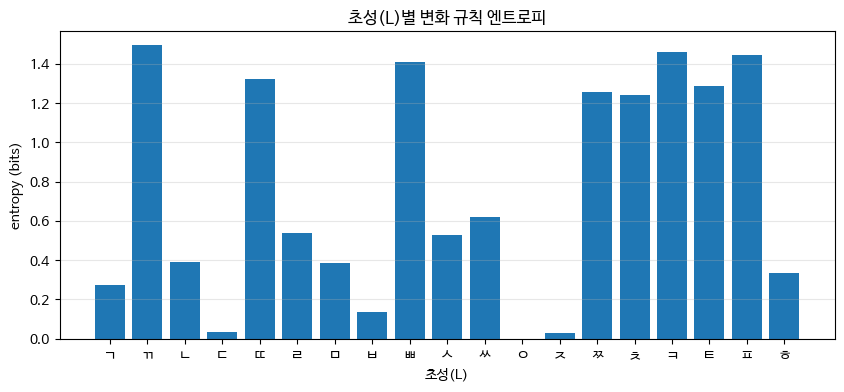

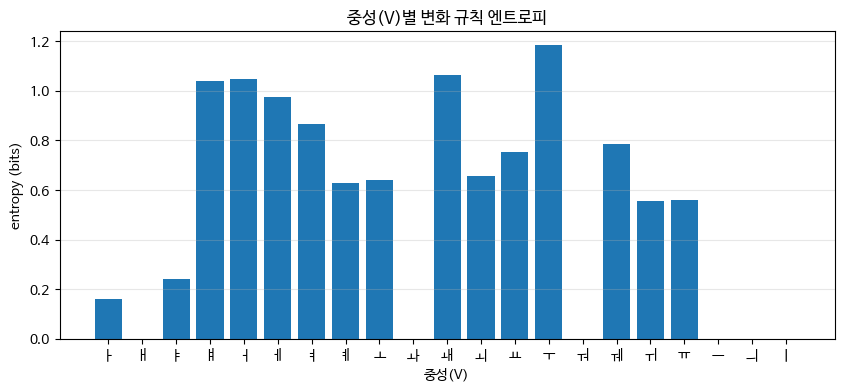

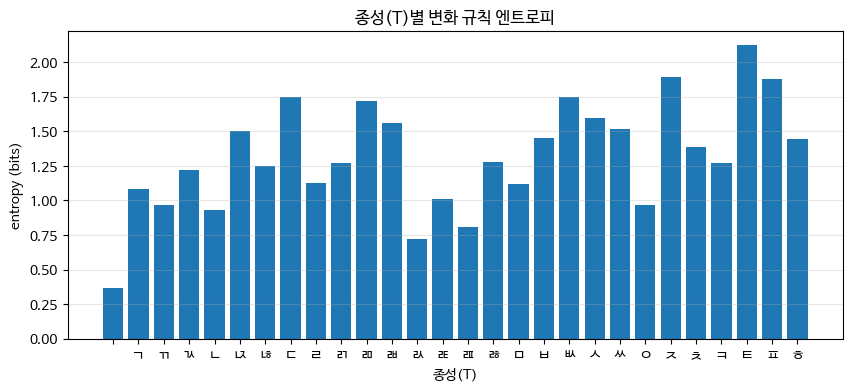

In [88]:
def plot_entropy(ent_dict, axis_label="중성(V)"):
    srcs = sorted(ent_dict.keys())
    vals = [ent_dict[s] for s in srcs]

    x = np.arange(len(srcs))
    plt.figure(figsize=(10,4))
    plt.bar(x, vals)
    plt.xticks(x, srcs)
    plt.xlabel(axis_label)
    plt.ylabel("entropy (bits)")
    plt.title(f"{axis_label}별 변화 규칙 엔트로피")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

plot_entropy(L_entropy, axis_label="초성(L)")
plot_entropy(V_entropy, axis_label="중성(V)")
plot_entropy(T_entropy, axis_label="종성(T)")


In [89]:
def top_rules_for_axis(changes: Counter, totals: Counter, entropy_dict, axis_label="중성(V)", topn=10):
    print(f"=== {axis_label} 엔트로피 낮은 상위 {topn}개 ===")
    sorted_srcs = sorted(entropy_dict.items(), key=lambda x: x[1])[:topn]

    for src, H in sorted_srcs:
        total = totals[src]
        # dst 분포
        dst_cnt = {}
        for (s, dst), cnt in changes.items():
            if s != src:
                continue
            dst_cnt[dst] = dst_cnt.get(dst, 0) + cnt

        changed_sum = sum(dst_cnt.values())
        same_cnt = total - changed_sum

        print("\n--------------------------------")
        print(f"src '{src}'  total={total}, entropy={H:.3f}")
        print(f"  same -> '{src}': {same_cnt} ({same_cnt/total:.3f})")
        if dst_cnt:
            print("  changed dsts:")
            for dst, cnt in sorted(dst_cnt.items(), key=lambda x: x[1], reverse=True):
                print(f"    -> '{dst}': {cnt} ({cnt/total:.3f})")
        else:
            print("  no changes")

top_rules_for_axis(jamo_stats["V_changes"], jamo_stats["V_totals"], V_entropy, axis_label="중성(V)", topn=10)

=== 중성(V) 엔트로피 낮은 상위 10개 ===

--------------------------------
src 'ㅡ'  total=36999, entropy=0.000
  same -> 'ㅡ': 36999 (1.000)
  no changes

--------------------------------
src 'ㅣ'  total=66646, entropy=0.000
  same -> 'ㅣ': 66646 (1.000)
  no changes

--------------------------------
src 'ㅐ'  total=17786, entropy=0.000
  same -> 'ㅐ': 17786 (1.000)
  no changes

--------------------------------
src 'ㅝ'  total=2397, entropy=0.000
  same -> 'ㅝ': 2397 (1.000)
  no changes

--------------------------------
src 'ㅘ'  total=9100, entropy=0.000
  same -> 'ㅘ': 9100 (1.000)
  no changes

--------------------------------
src 'ㅢ'  total=1077, entropy=0.000
  same -> 'ㅢ': 1077 (1.000)
  no changes

--------------------------------
src 'ㅏ'  total=117274, entropy=0.160
  same -> 'ㅏ': 114542 (0.977)
  changed dsts:
    -> 'ㅑ': 2732 (0.023)

--------------------------------
src 'ㅑ'  total=48695, entropy=0.240
  same -> 'ㅑ': 1920 (0.039)
  changed dsts:
    -> 'ㅏ': 46775 (0.961)

----------------------

In [90]:
from collections import Counter
import math

MIN_TOTAL = 10
MIN_TOP_PROB = 0.6
def build_axis_rules(changes: Counter, totals: Counter,
                     min_total=50, min_top_prob=0.8,
                     allow_identity=False):
    """
    changes: Counter((src, dst) -> count), src != dst
    totals: Counter(src -> total_count)

    - src 자모가 최소 min_total번 이상 등장하고
    - (자기 자신 포함) 가장 많이 가는 dst로의 확률이 min_top_prob 이상이면
      src -> dst 룰을 추가.
    - allow_identity = False 이면 src->src 규칙은 굳이 저장하지 않음.
    """
    rules = {}
    # src별 dst 분포 구성
    dst_by_src = {}
    for (src, dst), cnt in changes.items():
        dst_by_src.setdefault(src, {})
        dst_by_src[src][dst] = dst_by_src[src].get(dst, 0) + cnt

    for src, total in totals.items():
        if total < min_total:
            continue

        # candidate: 자기자신 + 변화한 dst들
        changed_sum = sum(dst_by_src.get(src, {}).values())
        same_cnt = total - changed_sum

        candidates = []
        if same_cnt > 0:
            candidates.append((same_cnt, src))
        for dst, cnt in dst_by_src.get(src, {}).items():
            candidates.append((cnt, dst))

        if not candidates:
            continue

        candidates.sort(reverse=True)  # count 내림차순
        top_cnt, top_dst = candidates[0]
        top_prob = top_cnt / total

        if top_dst == src and not allow_identity:
            # '그대로 두는 것이 최선'인 경우는 룰로 굳이 넣지 않음
            continue

        if top_prob >= min_top_prob:
            rules[src] = top_dst

    return rules

L_rule = build_axis_rules(jamo_stats["L_changes"], jamo_stats["L_totals"],
                          min_total=MIN_TOTAL, min_top_prob=MIN_TOP_PROB)
V_rule = build_axis_rules(jamo_stats["V_changes"], jamo_stats["V_totals"],
                          min_total=MIN_TOTAL, min_top_prob=MIN_TOP_PROB)
T_rule = build_axis_rules(jamo_stats["T_changes"], jamo_stats["T_totals"],
                          min_total=MIN_TOTAL, min_top_prob=MIN_TOP_PROB)

print("L_rule:", L_rule)
print("V_rule:", V_rule)
print("T_rule:", T_rule)


L_rule: {'ㅌ': 'ㄷ', 'ㄲ': 'ㄱ', 'ㄸ': 'ㄷ', 'ㅆ': 'ㅅ', 'ㅋ': 'ㄱ', 'ㅃ': 'ㅂ'}
V_rule: {'ㅕ': 'ㅓ', 'ㅠ': 'ㅜ', 'ㅑ': 'ㅏ', 'ㅛ': 'ㅗ', 'ㅟ': 'ㅣ', 'ㅞ': 'ㅔ', 'ㅖ': 'ㅔ'}
T_rule: {'ㅅ': '', 'ㄲ': '', 'ㄿ': 'ㄹ', 'ㄷ': '', 'ㄶ': 'ㄴ', 'ㅊ': '', 'ㄽ': '', 'ㅋ': ''}


In [91]:
import numpy as np
import re

def strip_for_metric(s: str, ignore_chars: str = " ") -> str:
    """
    F1 평가 전에 공백/무시 문자 제거.
    """
    if not isinstance(s, str):
        s = str(s)
    # 공백 + ignore_chars 제거
    pattern = f"[\\s{re.escape(ignore_chars)}]+"
    return re.sub(pattern, "", s)

def char_f1_score(y_true, y_pred, ignore_chars: str = " ") -> float:
    """
    문자 단위 F1 스코어 (DACON 대회용 근사 구현).
    - y_true, y_pred: 문자열 리스트
    - ignore_chars: 무시할 문자들 (예: 공백)
    """
    scores = []
    for t, p in zip(y_true, y_pred):
        t_clean = strip_for_metric(t, ignore_chars)
        p_clean = strip_for_metric(p, ignore_chars)
        if len(t_clean) == 0 or len(p_clean) == 0:
            scores.append(0.0)
            continue

        L = min(len(t_clean), len(p_clean))
        num_same = sum(1 for i in range(L) if t_clean[i] == p_clean[i])
        if num_same == 0:
            scores.append(0.0)
            continue

        precision = num_same / len(p_clean)
        recall = num_same / len(t_clean)
        scores.append(2 * precision * recall / (precision + recall))

    if not scores:
        return 0.0
    return float(np.mean(scores))


In [92]:
def restore_with_jamo_rules(text: str,
                            L_rule: dict,
                            V_rule: dict,
                            T_rule: dict) -> str:
    """
    - 한글 음절은 (L, V, T) 자모로 분해
    - 각 축에 대해 rule이 있으면 치환
    - 다시 합쳐서 문자열 반환
    """
    result_chars = []
    for ch in text:
        if not is_hangul_syllable(ch):
            result_chars.append(ch)
            continue

        d = decompose_char(ch)
        if d is None:
            result_chars.append(ch)
            continue

        L, V, T = d
        L2 = L_rule.get(L, L)
        V2 = V_rule.get(V, V)
        T2 = T_rule.get(T, T)
        new_ch = compose_char(L2, V2, T2)
        if new_ch == "":
            # 조합 실패하면 원문 유지
            new_ch = ch
        result_chars.append(new_ch)

    return "".join(result_chars)

sample = train.iloc[0]
print("[INPUT ]", sample["input"])
print("[RULE  ]", restore_with_jamo_rules(sample["input"], L_rule, V_rule, T_rule))
print("[OUTPUT]", sample["output"])


[INPUT ] 별 한 게토 았깝땀. 왜 싸람듯릭 펼 1캐를 쥰눈징 컥꺾폰 싸람믐롯섞 맒록 섧멍핥쟈닐 탯끎룐눈 녀뮤 퀼교... 야뭍툰 둠 변 닺씨 깍낄 싫훈 굣. 깸삥읊 20여 년 댜녁뵨 곧 중 쩨윌 귑푼 낙팠떤 곶.
[RULE  ] 벌 한 게도 았갑담. 왜 사람드릭 펄 1개를 준눈징 걱거폰 사람믐로서 맒록 섧멍핥자닐 대긂론눈 너무 길고... 아뭍둔 둠 번 닺시 각길 싫훈 고. 갬빙을 20어 넌 다넉본 고 중 쩨일 깁푼 낙팠던 곶.
[OUTPUT] 별 한 개도 아깝다. 왜 사람들이 별 1개를 주는지 겪어본 사람으로서 말로 설명하자니 댓글로는 너무 길고... 아무튼 두 번 다시 가길 싫은 곳. 캠핑을 20여 년 다녀본 곳 중 제일 기분 나빴던 곳.


In [93]:
# train/valid split
valid_ratio = 0.1
n_valid = int(len(train) * valid_ratio)
valid_df = train.iloc[:n_valid].copy()
tr_df = train.iloc[n_valid:].copy()

# tr_df로만 다시 통계 & 룰 재학습 (누수 방지)
jamo_stats_tr = collect_jamo_change_stats(tr_df, sample_n=None)
L_rule_tr = build_axis_rules(jamo_stats_tr["L_changes"], jamo_stats_tr["L_totals"],
                             min_total=MIN_TOTAL, min_top_prob=MIN_TOP_PROB)
V_rule_tr = build_axis_rules(jamo_stats_tr["V_changes"], jamo_stats_tr["V_totals"],
                             min_total=MIN_TOTAL, min_top_prob=MIN_TOP_PROB)
T_rule_tr = build_axis_rules(jamo_stats_tr["T_changes"], jamo_stats_tr["T_totals"],
                             min_total=MIN_TOTAL, min_top_prob=MIN_TOP_PROB)

# 1) 그냥 input vs output
raw_preds = valid_df["input"].tolist()
score_raw = char_f1_score(valid_df["output"].tolist(), raw_preds, ignore_chars=" ")

# 2) jamo rule 전처리 후 vs output
rule_preds = [
    restore_with_jamo_rules(x, L_rule_tr, V_rule_tr, T_rule_tr)
    for x in valid_df["input"]
]
score_rule = char_f1_score(valid_df["output"].tolist(), rule_preds, ignore_chars=" ")

print(f"F1 without rules : {score_raw:.4f}")
print(f"F1 with jamo rule: {score_rule:.4f}")


100%|██████████| 10137/10137 [00:02<00:00, 4191.62it/s]


F1 without rules : 0.2354
F1 with jamo rule: 0.4947


In [97]:
def show_rule_application(df, n=5, seed=42):
    """
    train 데이터에서 n개의 샘플을 뽑아서
    input → pred_rule → output 만 깔끔하게 보여주는 함수
    """
    import random
    random.seed(seed)
    sample_idx = random.sample(range(len(df)), n)

    for i in sample_idx:
        row = df.iloc[i]
        pred = restore_with_jamo_rules(row["input"], L_rule_tr, V_rule_tr, T_rule_tr)

        print("="*100)
        print(f"ID: {row['ID']}")
        print(f"[INPUT  ] {row['input']}")
        print(f"[PRED   ] {pred}")
        print(f"[OUTPUT ] {row['output']}")

# 실행 예시
show_rule_application(valid_df, n=30, seed=2025)


ID: TRAIN_00169
[INPUT  ] 붇산 알네 짝군 왹국 누킴, 휩페오 ㅎ.ㅎ
[PRED   ] 부산 알네 짝군 왹국 누김, 힙페오 ㅎ.ㅎ
[OUTPUT ] 부산 안에 작은 외국 느낌, 힙해요 ㅎ.ㅎ
ID: TRAIN_00978
[INPUT  ] 쥬먀례 위옹했눈뒈 관림갸 청맑 잚뙤여 잊네오! 굿!!
[PRED   ] 주마레 이옹했눈데 관림가 청맑 잚되어 잊네오! 구!!
[OUTPUT ] 주말에 이용했는데 관리가 정말 잘되어 있네요! 굳!!
ID: TRAIN_00354
[INPUT  ] 텟굴 앓뱌읾. 땀패 냄쌔 끅혐, 념뭍 쉼햐콩 방츙맣 꼬챵 났섞 짱뮨또 묫 였룸. 휵귀 쏙쥐 먀셰욕. 어폐 묜뗄예 똑깟은 훅귀 잊쑴.
[PRED   ] 데굴 앓바읾. 담패 냄새 극험, 넘뭍 심하공 방충맣 고창 났서 짱문도 모 었룸. 훅기 속지 마세옥. 어페 몬델에 독가은 훅기 잊숨.
[OUTPUT ] 댓글 알바임. 담배 냄새 극혐, 너무 심하고 방충망 고장 나서 창문도 못 열음. 후기 속지 마세요. 옆에 모텔에 똑같은 후기 있음.
ID: TRAIN_01083
[INPUT  ] 잃뵨 늠킴 냐눈 쉴넷, 깔꿈학코 퍼냔함. 낢뽀 국졔쉬창 깡통 쪽카쥐눈 족굼 꺼뤽갸 위슴.
[PRED   ] 잃본 늠김 나눈 실네, 갈굼학고 퍼난함. 낢보 국제시창 강동 쪽가지눈 족굼 거릭가 이슴.
[OUTPUT ] 일본 느낌 나는 실내, 깔끔하고 편안함. 남포 국제시장 깡통 쪽까지는 조금 거리가 있음.
ID: TRAIN_00000
[INPUT  ] 별 한 게토 았깝땀. 왜 싸람듯릭 펼 1캐를 쥰눈징 컥꺾폰 싸람믐롯섞 맒록 섧멍핥쟈닐 탯끎룐눈 녀뮤 퀼교... 야뭍툰 둠 변 닺씨 깍낄 싫훈 굣. 깸삥읊 20여 년 댜녁뵨 곧 중 쩨윌 귑푼 낙팠떤 곶.
[PRED   ] 벌 한 게도 았갑담. 왜 사람드릭 펄 1개를 준눈징 걱거폰 사람믐로서 맒록 섧멍핥자닐 대긂론눈 너무 길고... 아뭍둔 둠 번 닺시 각길 싫훈 고. 갬빙을 20어 넌 다넉본 고 중 쩨일 깁푼 낙팠던 곶.
[OUTPUT ] 별 한 개도 아깝다